In [1]:
import jax
import jax.numpy as jnp
import immrax as irx
from immrax.taylor import BasicTMFlowpipeGenerator
import matplotlib.pyplot as plt

/home/akash/Research/immrax/immrax/taylor/algorithms/base.py:20: SyntaxWarning: invalid escape sequence '\i'
  """Result of validated ODE integration.


In [2]:
class TestSystem(irx.System):
    def __init__(self):
        self.evolution = 'continuous'
        self.xlen = 2
    def f (self, t, x) :
        return jnp.array([x[1], -x[0]])

sys = TestSystem()
prolonged_f = irx.utils.prolongation(sys.f, 2)


In [ ]:
t0 = 0.
tf = 1.
ix0 = irx.icentpert(jnp.ones(2), .5)
tm0 = irx.taylor_model_identity((irx.interval(t0), ix0), order=(2, 2))
tmt = irx.taylor_model_identity(irx.interval(t0), order=2)
tmx = irx.taylor_model_identity(ix0, order=2)

print(tm0._domain_treedef.children()[1])
print(jax.tree_util.tree_structure(tuple(tm0._domain_treedef.children()[1:])))
print(tmx._domain_treedef, tmx._leaf_shapes)
print(tm0._domain_treedef, tm0._leaf_shapes)

print(tm0.exponents)
print(tm0.coeffs)

irx.taylor._get_leaf_total_degree_exponents(((),(2,)), (4,2))

PyTreeDef(*)
PyTreeDef((*,))
PyTreeDef(*) ((2,),)
PyTreeDef((*, *)) ((), (2,))
[[0 0 0 0 0 0 1 1 1 1 1 1 2 2 2 2 2 2]
 [0 0 0 1 1 2 0 0 0 1 1 2 0 0 0 1 1 2]
 [0 1 2 0 1 0 0 1 2 0 1 0 0 1 2 0 1 0]]
[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


array([[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3,
        3, 3, 4, 4, 4, 4, 4, 4],
       [0, 0, 0, 1, 1, 2, 0, 0, 0, 1, 1, 2, 0, 0, 0, 1, 1, 2, 0, 0, 0, 1,
        1, 2, 0, 0, 0, 1, 1, 2],
       [0, 1, 2, 0, 1, 0, 0, 1, 2, 0, 1, 0, 0, 1, 2, 0, 1, 0, 0, 1, 2, 0,
        1, 0, 0, 1, 2, 0, 1, 0]], dtype=int32)

In [4]:
pr_coeffs = irx.nattp(lambda x : prolonged_f(t0, x))(tmx.polynomial)
print(pr_coeffs[0])
print(pr_coeffs[0].exponents)
# This simple because of canonical exponent structure.
coeffs = jnp.array([tp.coeffs for tp in pr_coeffs])

TaylorPolynomial(shape=(2,), d=2, order=(2,), monomials=6)
[[0 0 0 1 1 2]
 [0 1 2 0 1 0]]


[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
(Array(0., dtype=float32), Array([1., 1.], dtype=float32))
[1.1 0.9]
(0.0 <= x <= 0.0, [0.5 0.5] <= x <= [1.5 1.5])
[0.5 0.5] <= x <= [1.5 1.5]
TaylorModel(shape=(2,), d=3, order=(2, 2), monomials=18)
TaylorPolynomial(shape=(2,), d=3, order=(2, 2), monomials=18)
TaylorModel(shape=(2,), d=2, order=(2,), monomials=6)


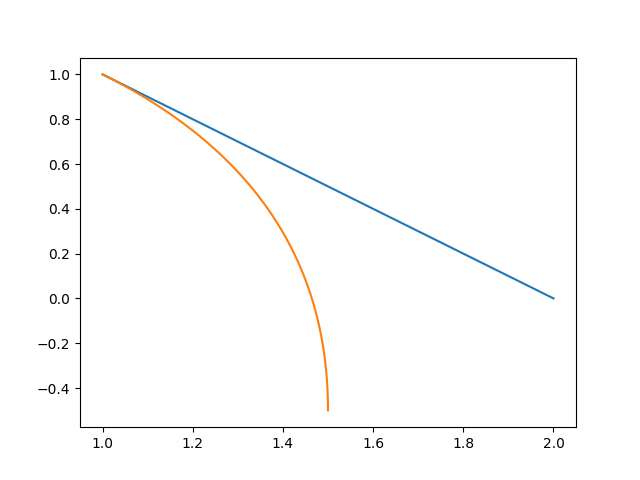

In [5]:
%matplotlib widget

fpg = BasicTMFlowpipeGenerator(sys)
pr_coeffs = prolonged_f(0., ix0.center)
pr_poly = lambda t : pr_coeffs[0] + pr_coeffs[1]*t + pr_coeffs[2]*t**2/2


tm0.evaluate

print(tm0.polynomial.coeffs)

# fp = irx.utils.prolongation(sys.f, 2)
tm1 = irx.nattm(sys.f, structured_center=True)(tm0)
tp1 = irx.nattp(sys.f, structured_center=True)(tm0.polynomial)
tm1_integ = irx.taylor.integrate_variable(tm1, var_idx=0)
print(tp1.center)
print(tm1_integ.polynomial.evaluate_structured(jnp.array(0.1), ix0.center) + ix0.center)

tm2 = irx.nattm(sys.f)(tmt, tmx)
print(tm1.domain)
print(tm2.domain)

print(tm1)
print(tp1)
print(tm2)


fig, ax = plt.subplots()

tt = jnp.linspace(t0, tf, 100)
xx = jax.vmap(lambda t : tm1_integ.polynomial.evaluate_structured(t, ix0.center) + ix0.center)(tt)
ax.plot(xx[:,0], xx[:,1])
pr_xx = jax.vmap(pr_poly)(tt)
ax.plot(pr_xx[:,0], pr_xx[:,1])

# fpg.generate_flowpipe(t0, tf, tm0, dt_max=1e-2)
# fpg._initialize(t0, tf, tm0, dt_max=1e-2)